# 02 — Bias Analysis

1. **Gender disparate impact** — Four-Fifths Rule (DI ratio)
2. **Age-based discrimination** — approval patterns across age groups
3. **Proxy variables** — non-protected attributes acting as proxies for protected characteristics
4. **Interaction effects** — combined influence of gender × age on decisions

---
### Sections
1. Setup & Load Clean Data
2. Gender Disparate Impact (DI Ratio — Four-Fifths Rule)
3. Age-Based Discrimination Patterns
4. Proxy Variable Analysis
5. Interaction Effects Between Attributes
6. Consolidated Summary & Regulatory Mapping

## 1. Setup & Load Clean Data

- Loads the cleaned dataset produced by `01_data_quality.ipynb` 
- Derives `age` from `date_of_birth` and bins it into 6 age groups (required for all age-based analyses downstream)

In [1]:
# Install fairlearn if not already present
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'fairlearn', '-q'])

CompletedProcess(args=['/Users/a.bauer/anaconda3/bin/python', '-m', 'pip', 'install', 'fairlearn', '-q'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency, norm
import warnings
warnings.filterwarnings('ignore')

try:
    from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
    FAIRLEARN_AVAILABLE = True
    print('✅ fairlearn loaded')
except ImportError:
    FAIRLEARN_AVAILABLE = False
    print('⚠️  fairlearn not available — DPD section will be skipped')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLOUR_MALE   = '#4C72B0'
COLOUR_FEMALE = '#DD8452'
THRESHOLD     = 0.8   # Four-Fifths Rule
np.random.seed(42)
print('Setup complete.')

✅ fairlearn loaded
Setup complete.


In [3]:
DATA_PATH = Path('../data/processed/clean_credit_applications.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('clean_dataset_view.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'Cleaned dataset not found. '
        'Run 01_data_quality.ipynb first and save to data/processed/clean_credit_applications.csv'
    )

df = pd.read_csv(DATA_PATH)

# Parse date columns safely
for col in ['date_of_birth', 'processing_timestamp']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Detect outcome column (handles both 'approved' and 'loan_approved')
if 'loan_approved' in df.columns:
    OUTCOME_COL = 'loan_approved'
elif 'approved' in df.columns:
    OUTCOME_COL = 'approved'
else:
    raise KeyError('No outcome column found. Expected "approved" or "loan_approved".')

df[OUTCOME_COL] = df[OUTCOME_COL].astype(int)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Outcome column: {OUTCOME_COL}')
print(f'Overall approval rate: {df[OUTCOME_COL].mean()*100:.1f}%')
df.head(3)

Dataset loaded: 499 rows x 21 columns
Outcome column: loan_approved
Overall approval rate: 58.1%


,_id,spending_behavior,processing_timestamp,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,...,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,loan_purpose,interest_rate,approved_amount,notes,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15 00:00:00+00:00,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,male,2001-03-09,10036,...,23.0,0.20,31212.0,0,algorithm_risk_score,NaN,NaN,NaN,NaN,25.0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaT,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,male,1992-03-31,10032,...,51.0,0.18,17915.0,0,algorithm_risk_score,NaN,NaN,NaN,NaN,33.0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaT,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,male,1989-10-24,10075,...,41.0,0.21,37909.0,1,NaN,vacation,3.7,59000.0,NaN,36.0


In [4]:
# ── Derive age from date_of_birth ─────────────────────────────────────────────
if 'date_of_birth' in df.columns:
    reference_date = df['processing_timestamp'].dt.date if 'processing_timestamp' in df.columns else pd.Timestamp('today')
    df['age'] = (pd.Timestamp('today') - df['date_of_birth']).dt.days // 365
    df['age'] = df['age'].where(df['age'].between(18, 100))  # sanity bounds

AGE_BINS   = [18, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_group'] = pd.cut(df['age'], bins=AGE_BINS, labels=AGE_LABELS, right=False)

print('Age distribution:')
print(df['age_group'].value_counts().sort_index())
print(f'\nRecords with unknown age: {df["age"].isna().sum()}')

Age distribution:
age_group
18–24     11
25–34    150
35–44    179
45–54     87
55–64     56
65+       13
Name: count, dtype: int64

Records with unknown age: 3


## 2. Gender Disparate Impact

$$DI = \frac{\text{Approval rate of unprivileged group}}{\text{Approval rate of privileged group}}$$

A value **below 0.8** indicates potential disparate impact requiring regulatory action.

- Computes approval rates for male vs. female and calculates the DI ratio (unprivileged/ privileged approval rate)
- Applies the Four-Fifths Rule: a DI below 0.8 is legally significant and triggers mandatory regulatory review
- Fairlearn's `demographic_parity_difference` cross-validates the result in absolute terms (gap = 0 is ideal)

In [5]:
df_gender = df[df['gender'].isin(['male', 'female'])].copy()

approval_stats = (
    df_gender
    .groupby('gender')[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
approval_stats['approval_rate_pct'] = (approval_stats['approval_rate'] * 100).round(2)
approval_stats['rejected_count']    = approval_stats['total'] - approval_stats['approved_count']

display(approval_stats.set_index('gender'))

,total,approved_count,approval_rate,approval_rate_pct,rejected_count
gender,,,,,
female,251,127,0.505976,50.60,124
male,248,163,0.657258,65.73,85


In [6]:
rate = approval_stats.set_index('gender')['approval_rate']

approval_rate_male   = rate['male']
approval_rate_female = rate['female']

if approval_rate_male >= approval_rate_female:
    privileged_rate, unprivileged_rate = approval_rate_male, approval_rate_female
    privileged_label, unprivileged_label = 'male', 'female'
else:
    privileged_rate, unprivileged_rate = approval_rate_female, approval_rate_male
    privileged_label, unprivileged_label = 'female', 'male'

DI_ratio = unprivileged_rate / privileged_rate

if DI_ratio < THRESHOLD:
    verdict  = '⚠️  DISPARATE IMPACT DETECTED'
    severity = 'Potential discrimination — regulatory review required.'
elif DI_ratio < 0.9:
    verdict  = '🔶  BORDERLINE'
    severity = 'Below ideal parity. Monitoring recommended.'
else:
    verdict  = '✅  PASSES FOUR-FIFTHS RULE'
    severity = 'Approval rates are roughly comparable across groups.'

print('=' * 55)
print('  DISPARATE IMPACT ANALYSIS — FOUR-FIFTHS RULE')
print('=' * 55)
print(f'  Privileged group   ({privileged_label:>6}):  {privileged_rate:.4f}  ({privileged_rate*100:.2f}%)')
print(f'  Unprivileged group ({unprivileged_label:>6}):  {unprivileged_rate:.4f}  ({unprivileged_rate*100:.2f}%)')
print('-' * 55)
print(f'  DI Ratio = {unprivileged_rate:.4f} / {privileged_rate:.4f} = {DI_ratio:.4f}')
print(f'  Threshold                            = {THRESHOLD}')
print('-' * 55)
print(f'  {verdict}')
print(f'  {severity}')
print('=' * 55)

  DISPARATE IMPACT ANALYSIS — FOUR-FIFTHS RULE
  Privileged group   (  male):  0.6573  (65.73%)
  Unprivileged group (female):  0.5060  (50.60%)
-------------------------------------------------------
  DI Ratio = 0.5060 / 0.6573 = 0.7698
  Threshold                            = 0.8
-------------------------------------------------------
  ⚠️  DISPARATE IMPACT DETECTED
  Potential discrimination — regulatory review required.


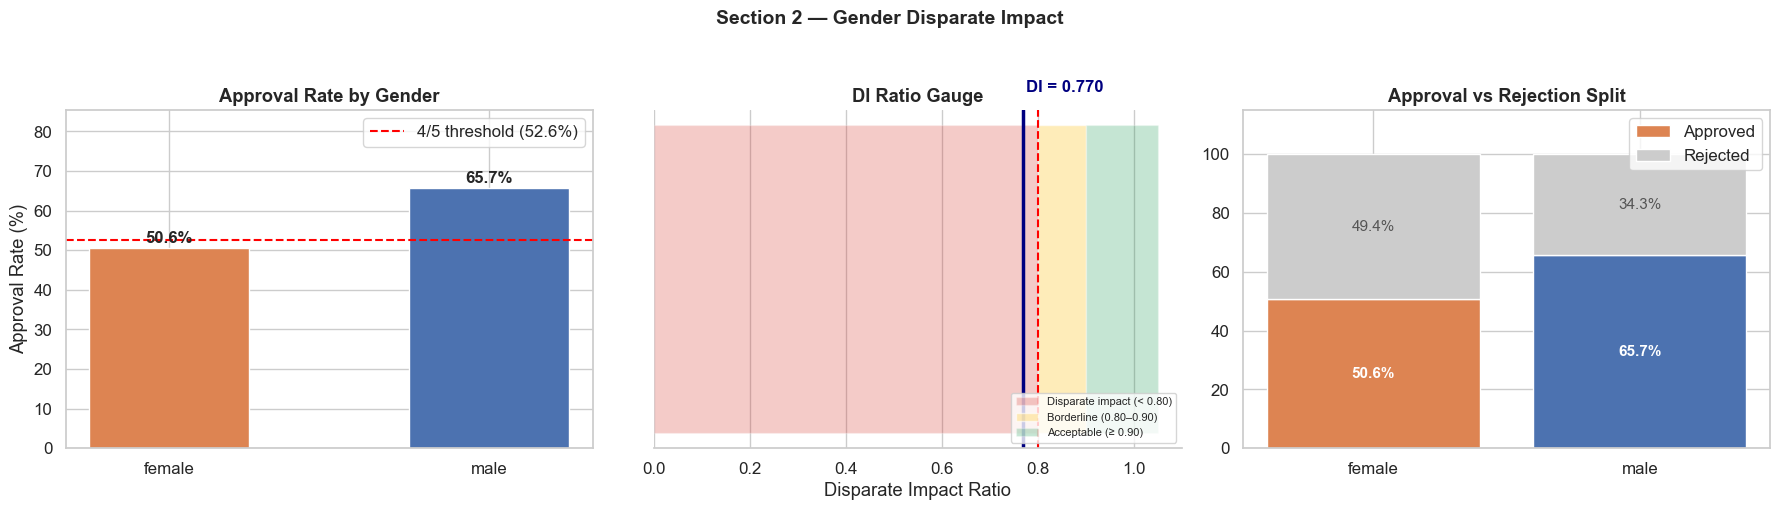

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colours = {'male': COLOUR_MALE, 'female': COLOUR_FEMALE}

# ---- Left: approval rate bars ----
ax1 = axes[0]
bars = ax1.bar(
    approval_stats['gender'],
    approval_stats['approval_rate_pct'],
    color=[colours[g] for g in approval_stats['gender']],
    edgecolor='white', width=0.5
)
for bar, val in zip(bars, approval_stats['approval_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
threshold_pct = privileged_rate * THRESHOLD * 100
ax1.axhline(threshold_pct, color='red', linestyle='--', linewidth=1.5,
            label=f'4/5 threshold ({threshold_pct:.1f}%)')
ax1.set_title('Approval Rate by Gender', fontweight='bold')
ax1.set_ylabel('Approval Rate (%)')
ax1.set_ylim(0, max(approval_stats['approval_rate_pct']) * 1.3)
ax1.legend()

# ---- Middle: DI gauge ----
ax2 = axes[1]
ax2.barh(['DI Ratio'], [0.80], color='#d73027', alpha=0.25, height=0.5, label='Disparate impact (< 0.80)')
ax2.barh(['DI Ratio'], [0.10], left=0.80, color='#fee08b', alpha=0.6,  height=0.5, label='Borderline (0.80–0.90)')
ax2.barh(['DI Ratio'], [0.15], left=0.90, color='#1a9850', alpha=0.25, height=0.5, label='Acceptable (≥ 0.90)')
ax2.axvline(DI_ratio, color='navy', linewidth=2.5)
ax2.text(DI_ratio + 0.005, 0.3, f'DI = {DI_ratio:.3f}',
         va='bottom', ha='left', fontsize=12, fontweight='bold', color='navy')
ax2.axvline(THRESHOLD, color='red', linewidth=1.5, linestyle='--')
ax2.set_xlim(0, 1.1)
ax2.set_xlabel('Disparate Impact Ratio')
ax2.set_title('DI Ratio Gauge', fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)
ax2.set_yticks([])
sns.despine(ax=ax2, left=True)

# ---- Right: stacked pct ----
ax3 = axes[2]
genders       = approval_stats['gender'].tolist()
approved_pcts = approval_stats['approval_rate_pct'].tolist()
rejected_pcts = (100 - approval_stats['approval_rate_pct']).tolist()
ax3.bar(genders, approved_pcts, color=[colours[g] for g in genders], label='Approved', edgecolor='white')
ax3.bar(genders, rejected_pcts, bottom=approved_pcts, color='#cccccc', label='Rejected', edgecolor='white')
for i, (a, r) in enumerate(zip(approved_pcts, rejected_pcts)):
    ax3.text(i, a/2,   f'{a:.1f}%', ha='center', va='center', fontweight='bold', color='white',   fontsize=11)
    ax3.text(i, a+r/2, f'{r:.1f}%', ha='center', va='center', color='#555', fontsize=11)
ax3.set_title('Approval vs Rejection Split', fontweight='bold')
ax3.set_ylim(0, 115)
ax3.legend()

plt.suptitle('Section 2 — Gender Disparate Impact', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
Path('../reports').mkdir(parents=True, exist_ok=True)
plt.savefig('../reports/bias_gender_di.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
if FAIRLEARN_AVAILABLE:
    y_true      = df_gender[OUTCOME_COL].values
    sensitive_f = df_gender['gender'].values
    dpd = demographic_parity_difference(y_true=y_true, y_pred=y_true, sensitive_features=sensitive_f)
    dpr = demographic_parity_ratio(     y_true=y_true, y_pred=y_true, sensitive_features=sensitive_f)
    print(f'Demographic Parity Difference : {dpd:+.4f}  (ideal = 0)')
    print(f'Demographic Parity Ratio      :  {dpr:.4f}  (ideal = 1)')
else:
    print('fairlearn not available')

Demographic Parity Difference : +0.1513  (ideal = 0)
Demographic Parity Ratio      :  0.7698  (ideal = 1)


In [9]:
# ── Statistical tests — Gender vs Approval ───────────────────────────────────

# ---- 1. Chi-square test -------------------------------------------------------
contingency_gender = pd.crosstab(df_gender['gender'], df_gender[OUTCOME_COL])
chi2_g, p_chi2_g, dof_g, _ = chi2_contingency(contingency_gender)

# ---- 2. Two-proportion z-test (more precise for exactly 2 groups) ------------
n_male   = approval_stats.set_index('gender').loc['male',   'total']
n_female = approval_stats.set_index('gender').loc['female', 'total']
x_male   = approval_stats.set_index('gender').loc['male',   'approved_count']
x_female = approval_stats.set_index('gender').loc['female', 'approved_count']

p_pool  = (x_male + x_female) / (n_male + n_female)
se      = np.sqrt(p_pool * (1 - p_pool) * (1/n_male + 1/n_female))
z_stat  = (approval_rate_male - approval_rate_female) / se
p_ztest = 2 * (1 - norm.cdf(abs(z_stat)))   # two-tailed

# ---- 3. Effect size: Cramér's V ----------------------------------------------
n_total   = len(df_gender)
cramers_v = np.sqrt(chi2_g / (n_total * (min(contingency_gender.shape) - 1)))

print('=' * 55)
print('  STATISTICAL TESTS — GENDER vs APPROVAL')
print('=' * 55)
print(f'  1. Chi-square test:')
print(f'     χ² = {chi2_g:.4f},  p = {p_chi2_g:.6f},  df = {dof_g}')
print()
print(f'  2. Two-proportion z-test:')
print(f'     z  = {z_stat:.4f},  p = {p_ztest:.6f}')
print()
print(f'  3. Effect size (Cramér\'s V): {cramers_v:.4f}')
print(f'     (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)')
print('-' * 55)
if p_ztest < 0.05:
    print('  ⚠️  Statistically significant gender gap in approval (p < 0.05)')
    print('     The DI ratio reflects a real pattern, not random variation.')
else:
    print('  ✅ Gender gap is not statistically significant (p ≥ 0.05)')
    print('     The DI ratio may reflect sampling noise.')
print('=' * 55)

  STATISTICAL TESTS — GENDER vs APPROVAL
  1. Chi-square test:
     χ² = 11.1156,  p = 0.000856,  df = 1

  2. Two-proportion z-test:
     z  = 3.4247,  p = 0.000615

  3. Effect size (Cramér's V): 0.1493
     (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)
-------------------------------------------------------
  ⚠️  Statistically significant gender gap in approval (p < 0.05)
     The DI ratio reflects a real pattern, not random variation.


## 3. Age-Based Discrimination Patterns

Age is a protected characteristic under EU non-discrimination law.  
We examine whether approval rates differ materially across age groups  
and compute the DI ratio for each group relative to the highest-approval group.

- Computes approval rates and DI ratios for each age group, flagging any group falling below the 0.8 threshold
- A chi-square test confirms whether the age–approval relationship is statistically significant or could be due to chance



In [10]:
df_age = df.dropna(subset=['age_group', OUTCOME_COL]).copy()

age_stats = (
    df_age
    .groupby('age_group', observed=True)[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
age_stats['approval_rate_pct'] = (age_stats['approval_rate'] * 100).round(2)
age_stats['rejected_count']    = age_stats['total'] - age_stats['approved_count']

# DI ratio: each group vs the group with the highest approval rate
max_rate = age_stats['approval_rate'].max()
age_stats['DI_ratio'] = (age_stats['approval_rate'] / max_rate).round(4)
age_stats['DI_flag']  = age_stats['DI_ratio'].apply(
    lambda x: '⚠️  Disparate impact' if x < 0.8 else ('🔶 Borderline' if x < 0.9 else '✅ OK')
)

print('=== Age Group Approval Rates ===')
display(age_stats.set_index('age_group'))

=== Age Group Approval Rates ===


,total,approved_count,approval_rate,approval_rate_pct,rejected_count,DI_ratio,DI_flag
age_group,,,,,,,
18–24,11,6,0.545455,54.55,5,0.8345,🔶 Borderline
25–34,150,67,0.446667,44.67,83,0.6834,⚠️ Disparate impact
35–44,179,117,0.653631,65.36,62,1.0000,✅ OK
45–54,87,56,0.643678,64.37,31,0.9848,✅ OK
55–64,56,35,0.625000,62.50,21,0.9562,✅ OK
65+,13,7,0.538462,53.85,6,0.8238,🔶 Borderline


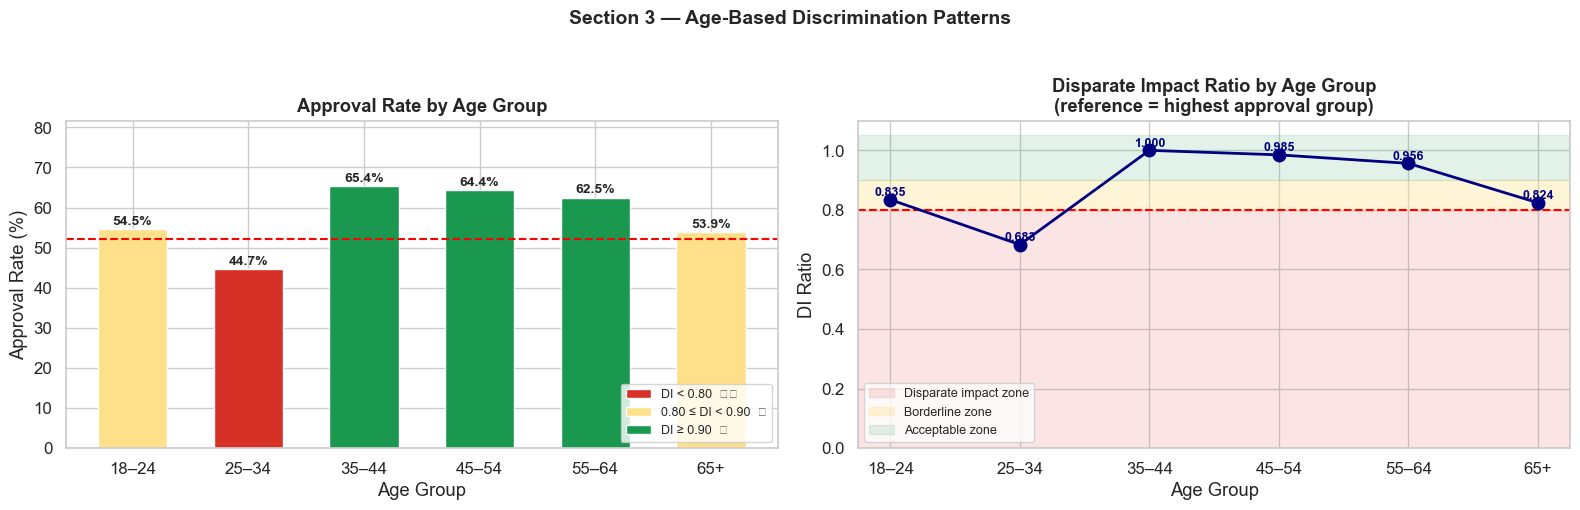

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Left: approval rate by age group ----
ax1 = axes[0]
bar_colours = ['#d73027' if di < 0.8 else ('#fee08b' if di < 0.9 else '#1a9850')
               for di in age_stats['DI_ratio']]
bars = ax1.bar(age_stats['age_group'].astype(str), age_stats['approval_rate_pct'],
               color=bar_colours, edgecolor='white', width=0.6)
for bar, val in zip(bars, age_stats['approval_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.axhline(max_rate * THRESHOLD * 100, color='red', linestyle='--', linewidth=1.5,
            label=f'4/5 threshold ({max_rate * THRESHOLD * 100:.1f}%)')
ax1.set_title('Approval Rate by Age Group', fontweight='bold')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Approval Rate (%)')
ax1.set_ylim(0, max(age_stats['approval_rate_pct']) * 1.25)
ax1.legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d73027', label='DI < 0.80  ⚠️'),
                   Patch(facecolor='#fee08b', label='0.80 ≤ DI < 0.90  🔶'),
                   Patch(facecolor='#1a9850', label='DI ≥ 0.90  ✅')]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)

# ---- Right: DI ratio by age group ----
ax2 = axes[1]
ax2.axhspan(0,    0.80, color='#d73027', alpha=0.12, label='Disparate impact zone')
ax2.axhspan(0.80, 0.90, color='#fee08b', alpha=0.35, label='Borderline zone')
ax2.axhspan(0.90, 1.05, color='#1a9850', alpha=0.12, label='Acceptable zone')
ax2.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax2.plot(age_stats['age_group'].astype(str), age_stats['DI_ratio'],
         marker='o', markersize=9, color='navy', linewidth=2, zorder=5)
for i, row in age_stats.iterrows():
    ax2.text(i, row['DI_ratio'] + 0.012, f"{row['DI_ratio']:.3f}",
             ha='center', fontsize=9, fontweight='bold', color='navy')
ax2.set_title('Disparate Impact Ratio by Age Group\n(reference = highest approval group)', fontweight='bold')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('DI Ratio')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)

plt.suptitle('Section 3 — Age-Based Discrimination Patterns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/bias_age_discrimination.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Statistical tests — Age Group vs Approval ───────────────────────────────

# ---- 1. Chi-square test ------------------------------------------------------
contingency_age = pd.crosstab(df_age['age_group'], df_age[OUTCOME_COL])
chi2_age, p_value, dof_age, _ = chi2_contingency(contingency_age)

# ---- 2. Effect size: Cramér's V ----------------------------------------------
n_age     = len(df_age)
cramers_v_age = np.sqrt(chi2_age / (n_age * (min(contingency_age.shape) - 1)))

print('=' * 55)
print('  STATISTICAL TESTS — AGE GROUP vs APPROVAL')
print('=' * 55)
print(f'  Chi-square test:')
print(f'    χ² = {chi2_age:.4f},  p = {p_value:.6f},  df = {dof_age}')
print()
print(f'  Effect size (Cramér\'s V): {cramers_v_age:.4f}')
print(f'    (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)')
print('-' * 55)
if p_value < 0.05:
    print('  ⚠️  Statistically significant association between age group and approval (p < 0.05).')
    print('     This does not prove causation but warrants further investigation.')
else:
    print('  ✅ No statistically significant association detected (p ≥ 0.05).')
print('=' * 55)

  STATISTICAL TESTS — AGE GROUP vs APPROVAL
  Chi-square test:
    χ² = 16.9968,  p = 0.004506,  df = 5

  Effect size (Cramér's V): 0.1851
    (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)
-------------------------------------------------------
  ⚠️  Statistically significant association between age group and approval (p < 0.05).
     This does not prove causation but warrants further investigation.


## 4. Proxy Variable Analysis

A **proxy variable** is a non-protected feature that is highly correlated with a protected attribute  
(gender, age) AND with the outcome. If the model uses such a feature, it can produce  
discriminatory outcomes even without directly using the protected attribute.

**Method:**  
1. Compute correlation of each numeric feature with `gender` (point-biserial) and `age`  
2. Compute correlation of each numeric feature with the approval outcome  
3. Flag features that score high on **both** — these are proxy risks


- Measures how strongly each numeric feature correlates with both a protected attribute (gender, age) and the outcome
- Features scoring high on both are proxy risks — the model can discriminate through them even without directly using gender or age
- Results are ranked by a proxy risk score and visualised as a bubble chart to make trade-offs visible at a glance

In [13]:
df_proxy = df.copy()
df_proxy['gender_binary'] = (df_proxy['gender'] == 'male').astype(float)

# Numeric features to test (exclude protected attrs and outcome itself)
EXCLUDE = {OUTCOME_COL, 'gender', 'gender_binary', 'age', '_id',
           'processing_timestamp', 'date_of_birth', 'age_group'}
numeric_cols = [c for c in df_proxy.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]

print(f'Features tested: {numeric_cols}')

results = []
for col in numeric_cols:
    valid = df_proxy[[col, 'gender_binary', 'age', OUTCOME_COL]].dropna()
    if len(valid) < 30:
        continue

    # Correlation with gender
    r_gender, p_gender = pointbiserialr(valid['gender_binary'], valid[col])

    # Correlation with age
    r_age,    p_age    = stats.pearsonr(valid['age'], valid[col])

    # Correlation with outcome
    r_outcome, p_outcome = pointbiserialr(valid[OUTCOME_COL], valid[col])

    # Proxy risk score: high correlation with BOTH a protected attr AND the outcome
    proxy_score = max(abs(r_gender), abs(r_age)) * abs(r_outcome)

    results.append({
        'feature':              col,
        'corr_gender':          round(r_gender,  3),
        'p_gender':             round(p_gender,  4),
        'corr_age':             round(r_age,     3),
        'p_age':                round(p_age,     4),
        'corr_outcome':         round(r_outcome, 3),
        'p_outcome':            round(p_outcome, 4),
        'proxy_risk_score':     round(proxy_score, 4),
    })

proxy_df = pd.DataFrame(results).sort_values('proxy_risk_score', ascending=False)

# Flag risk levels


def flag_risk(score):
    if score > 0.15:  return '🔴 High proxy risk'
    if score > 0.07:  return '🟡 Medium proxy risk'
    return '🟢 Low proxy risk'

proxy_df['risk_flag'] = proxy_df['proxy_risk_score'].apply(flag_risk)

print('\n=== Proxy Variable Analysis ===')
display(proxy_df.set_index('feature'))

Features tested: ['zip_code', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'interest_rate', 'approved_amount']

=== Proxy Variable Analysis ===


,corr_gender,p_gender,corr_age,p_age,corr_outcome,p_outcome,proxy_risk_score,risk_flag
feature,,,,,,,,
zip_code,-0.805,0.0000,0.045,0.3157,-0.120,0.0073,0.0969,🟡 Medium proxy risk
credit_history_months,-0.021,0.6372,0.649,0.0000,0.147,0.0010,0.0955,🟡 Medium proxy risk
annual_income,-0.042,0.3501,0.394,0.0000,0.180,0.0001,0.0709,🟡 Medium proxy risk
savings_balance,-0.002,0.9731,0.286,0.0000,0.134,0.0027,0.0384,🟢 Low proxy risk
debt_to_income,0.054,0.2267,-0.069,0.1251,-0.001,0.9787,0.0001,🟢 Low proxy risk
interest_rate,0.056,0.3455,0.085,0.1499,NaN,NaN,NaN,🟢 Low proxy risk
approved_amount,0.067,0.2596,0.085,0.1506,NaN,NaN,NaN,🟢 Low proxy risk


`Interest_rate` and `approved_amount` are post-decision fields — they only have values when a loan was approved, so they're NaN for every rejected application.

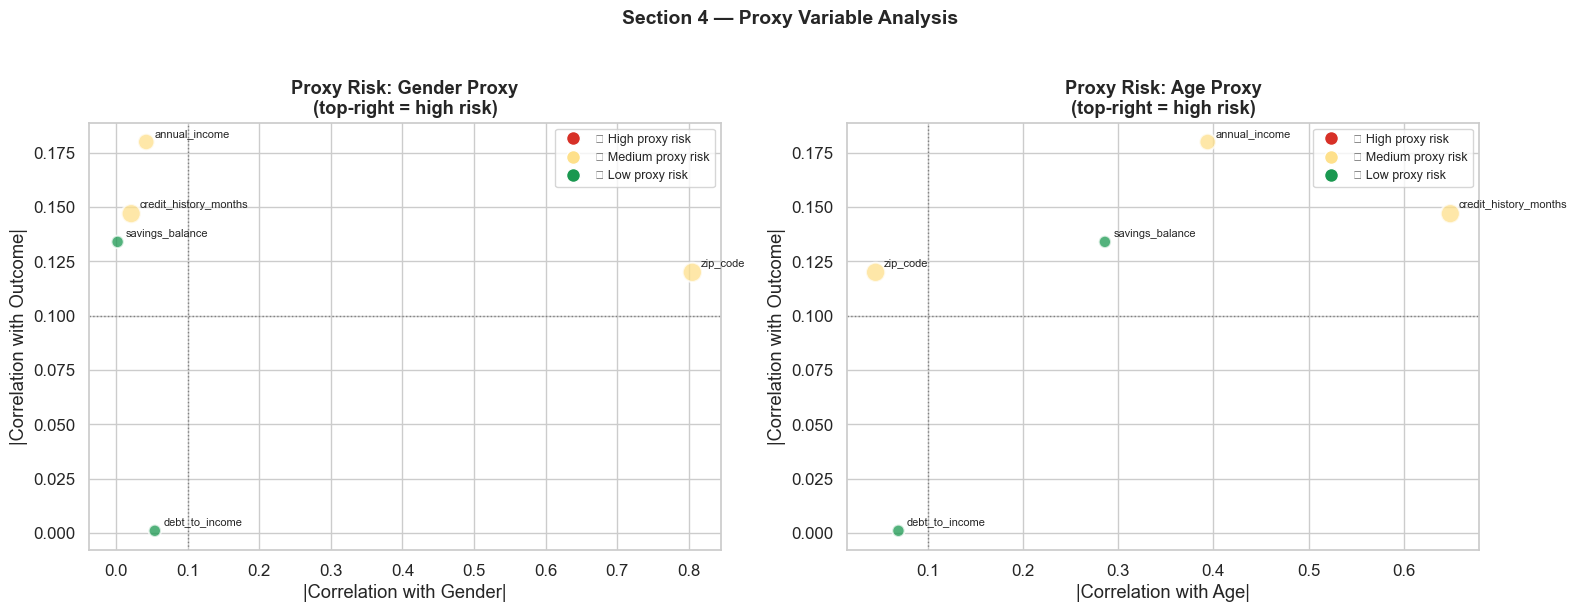

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colour_map = {'🔴 High proxy risk': '#d73027', '🟡 Medium proxy risk': '#fee08b', '🟢 Low proxy risk': '#1a9850'}

for ax, x_col, x_label, title in [
    (axes[0], 'corr_gender', '|Correlation with Gender|', 'Proxy Risk: Gender Proxy\n(top-right = high risk)'),
    (axes[1], 'corr_age',    '|Correlation with Age|',    'Proxy Risk: Age Proxy\n(top-right = high risk)')
]:
    # Drop rows with NaN in any column we need — this is the root cause of the crash
    plot_data = proxy_df[['feature', x_col, 'corr_outcome', 'proxy_risk_score', 'risk_flag']].dropna().copy()
    plot_data['x'] = plot_data[x_col].abs()
    plot_data['y'] = plot_data['corr_outcome'].abs()
    plot_data['s'] = (plot_data['proxy_risk_score'].abs() * 2000).clip(lower=80)
    plot_data['c'] = plot_data['risk_flag'].map(colour_map)

    ax.scatter(plot_data['x'], plot_data['y'],
               s=plot_data['s'].values,
               c=plot_data['c'].values,
               alpha=0.75, edgecolors='white', linewidth=1.5)

    for _, row in plot_data.iterrows():
        ax.annotate(row['feature'], (row['x'], row['y']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

    ax.axvline(0.1, color='grey', linestyle=':', linewidth=1)
    ax.axhline(0.1, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel(x_label)
    ax.set_ylabel('|Correlation with Outcome|')
    ax.set_title(title, fontweight='bold')

from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l)
              for l, c in colour_map.items()]
axes[0].legend(handles=legend_els, fontsize=9)
axes[1].legend(handles=legend_els, fontsize=9)

plt.suptitle('Section 4 — Proxy Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/bias_proxy_variables.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# muss irgendwo besser eingefügt werde
proxy_df['max_protected_corr'] = proxy_df[['corr_gender','corr_age']].abs().max(axis=1)

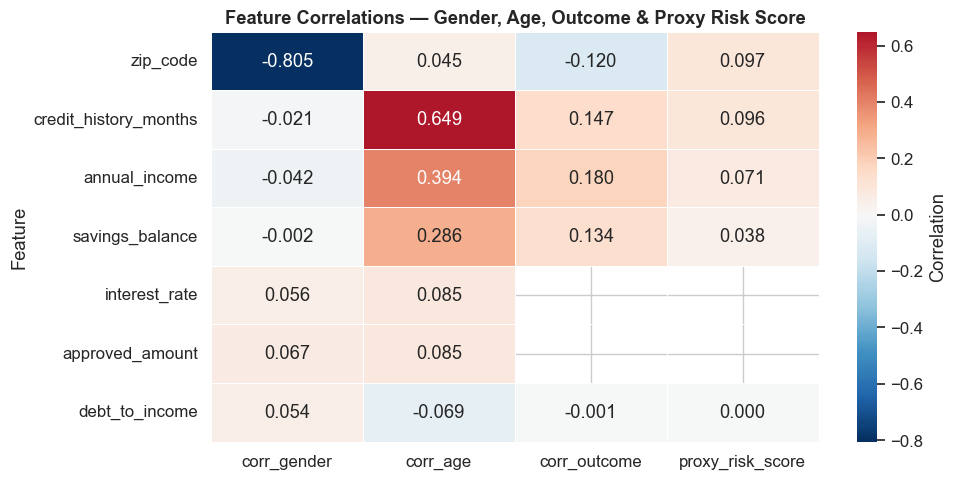


🔴 High-risk proxy features:
  None detected

🟡 Medium-risk proxy features:
  ['zip_code', 'credit_history_months', 'annual_income']


In [16]:
# ── Correlation heatmap: all numeric features vs outcome ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Ensure column exists
proxy_df['max_protected_corr'] = proxy_df[['corr_gender','corr_age']].abs().max(axis=1)

# Sort BEFORE selecting columns — max_protected_corr is dropped after
corr_outcome = (
    proxy_df
    .sort_values('max_protected_corr', ascending=False)   # sort on full df
    .set_index('feature')
    [['corr_gender','corr_age','corr_outcome','proxy_risk_score']]  # then select
)

sns.heatmap(corr_outcome, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlations — Gender, Age, Outcome & Proxy Risk Score', fontweight='bold')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/bias_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔴 High-risk proxy features:')
high_risk = proxy_df[proxy_df['risk_flag'] == '🔴 High proxy risk']['feature'].tolist()
print(' ', high_risk if high_risk else 'None detected')
print('\n🟡 Medium-risk proxy features:')
medium_risk = proxy_df[proxy_df['risk_flag'] == '🟡 Medium proxy risk']['feature'].tolist()
print(' ', medium_risk if medium_risk else 'None detected')

## 5. Interaction Effects Between Attributes

Interaction effects occur when the combination of two protected attributes produces  
a discriminatory pattern that neither attribute alone would reveal.

**Analyses:**
- Approval rate heatmap: gender × age group
- DI ratio for each gender × age subgroup
- Statistical test for interaction significance


Examines every gender × age group combination (12 subgroups) to detect intersectional bias — patterns invisible when looking at gender or age alone

In [17]:
df_interact = df_gender.dropna(subset=['age_group']).copy()

# ── Approval rate: gender × age group ─────────────────────────────────────────
interaction_stats = (
    df_interact
    .groupby(['age_group', 'gender'], observed=True)[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
interaction_stats['approval_rate_pct'] = (interaction_stats['approval_rate'] * 100).round(2)

# DI ratio for each subgroup vs overall max
global_max_rate = interaction_stats['approval_rate'].max()
interaction_stats['DI_ratio'] = (interaction_stats['approval_rate'] / global_max_rate).round(4)

display(interaction_stats.set_index(['age_group','gender']))

total  approved_count  approval_rate  approval_rate_pct  \
age_group gender                                                            
18–24     female      6               3       0.500000              50.00   
          male        5               3       0.600000              60.00   
25–34     female     79              27       0.341772              34.18   
          male       71              40       0.563380              56.34   
35–44     female     85              50       0.588235              58.82   
          male       94              67       0.712766              71.28   
45–54     female     40              25       0.625000              62.50   
          male       47              31       0.659574              65.96   
55–64     female     31              17       0.548387              54.84   
          male       25              18       0.720000              72.00   
65+       female      8               4       0.500000              50.00   
          male        5               3       0.600000              60.00   

                  DI_ratio  
age_group gender            
18–24     female    0.6944  
          male      0.8333  
25–34     female    0.4747  
          male      0.7825  
35–44     female    0.8170  
          male      0.9900  
45–54     female    0.8681  
          male      0.9161  
55–64     female    0.7616  
          male      1.0000  
65+       female    0.6944  
          male      0.8333

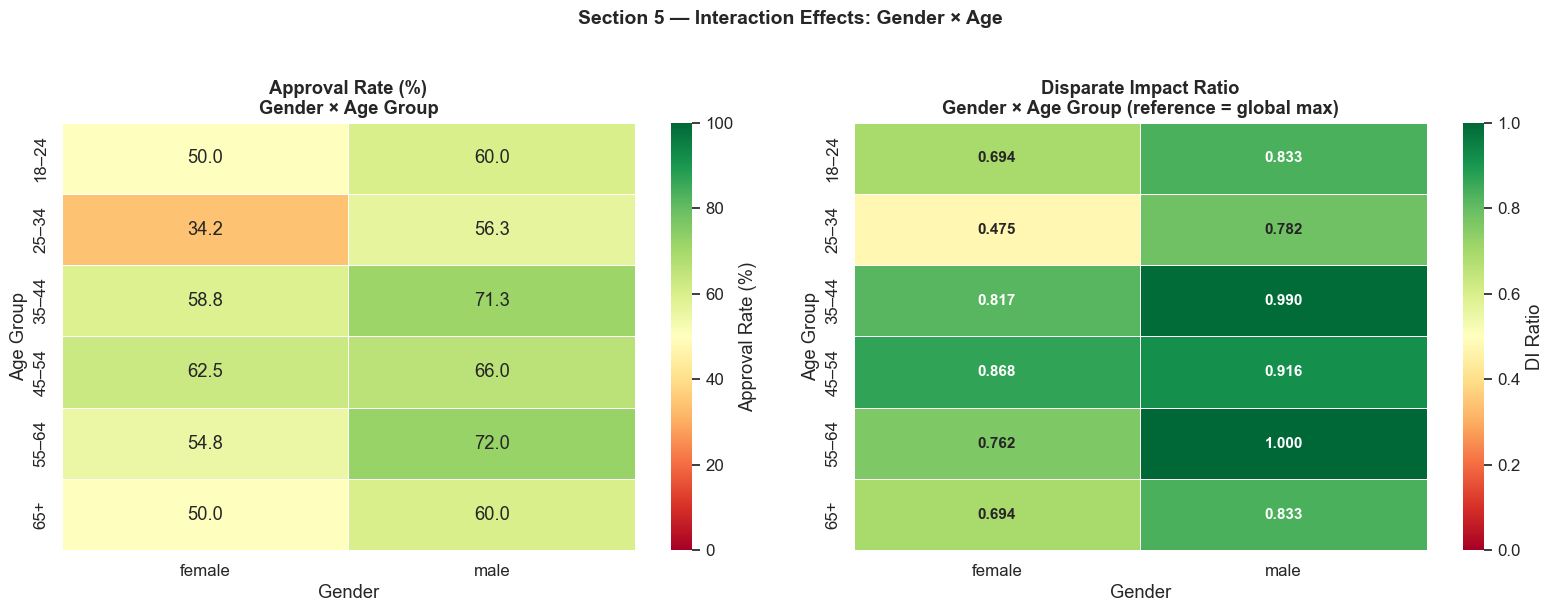

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left: heatmap approval rate ----
ax1 = axes[0]
pivot_rate = interaction_stats.pivot(index='age_group', columns='gender', values='approval_rate_pct')
sns.heatmap(pivot_rate, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5,
            ax=ax1, cbar_kws={'label': 'Approval Rate (%)'}, vmin=0, vmax=100)
ax1.set_title('Approval Rate (%)\nGender × Age Group', fontweight='bold')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Age Group')

# ---- Right: DI ratio heatmap ----
ax2 = axes[1]
pivot_di = interaction_stats.pivot(index='age_group', columns='gender', values='DI_ratio')
sns.heatmap(pivot_di, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5,
            ax=ax2, cbar_kws={'label': 'DI Ratio'}, vmin=0, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'})
ax2.set_title('Disparate Impact Ratio\nGender × Age Group (reference = global max)', fontweight='bold')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Age Group')

plt.suptitle('Section 5 — Interaction Effects: Gender × Age', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/bias_interaction_effects.png', dpi=150, bbox_inches='tight')
plt.show()

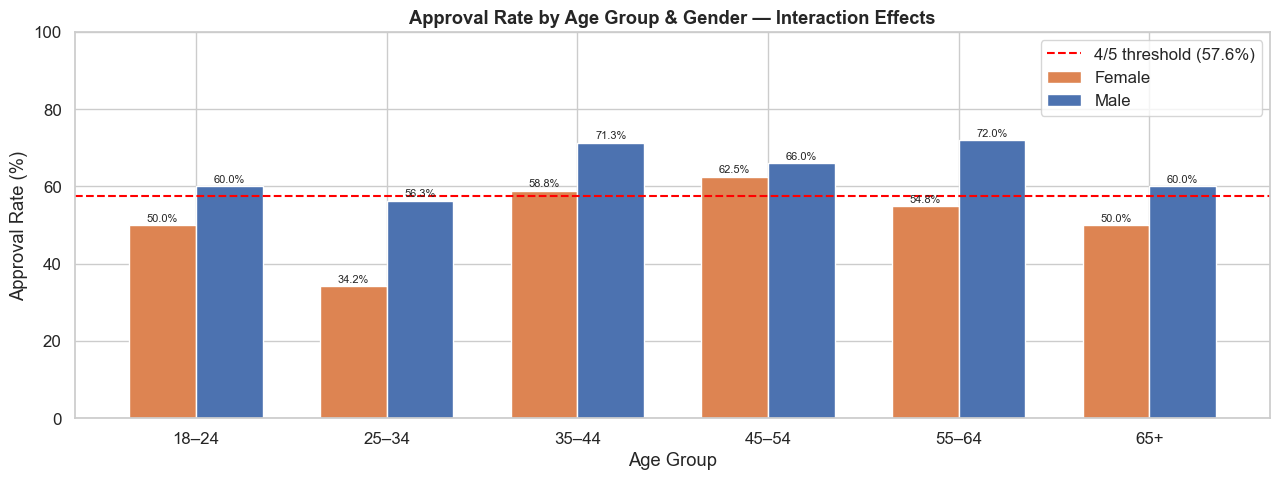

In [19]:
# ── Grouped bar chart: approval rate by age group, split by gender ────────────
fig, ax = plt.subplots(figsize=(13, 5))
colours = {'male': COLOUR_MALE, 'female': COLOUR_FEMALE}

pivot_rate = interaction_stats.pivot(index='age_group', columns='gender', values='approval_rate_pct')
x = np.arange(len(pivot_rate))
width = 0.35

for i, gender in enumerate(pivot_rate.columns):
    bars = ax.bar(x + (i - 0.5) * width, pivot_rate[gender], width,
                  label=gender.capitalize(), color=colours[gender], edgecolor='white')
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.axhline(global_max_rate * THRESHOLD * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'4/5 threshold ({global_max_rate * THRESHOLD * 100:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(pivot_rate.index)
ax.set_xlabel('Age Group')
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Approval Rate by Age Group & Gender — Interaction Effects', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/bias_interaction_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Highlight intersectional subgroups below DI threshold ────────────────────
below_threshold = interaction_stats[interaction_stats['DI_ratio'] < THRESHOLD].copy()
print(f'Subgroups with DI < {THRESHOLD} (intersectional disparate impact):')
if len(below_threshold) == 0:
    print('  None — all gender × age subgroups pass the Four-Fifths Rule. ✅')
else:
    print(f'  {len(below_threshold)} subgroup(s) flagged:')
    display(below_threshold[['age_group','gender','approval_rate_pct','DI_ratio']].set_index(['age_group','gender']))
    print()
    print('⚠️  Intersectional discrimination: these groups face compounded disadvantage.')
    print('   A bias fix addressing gender alone or age alone would miss these subgroups.')

Subgroups with DI < 0.8 (intersectional disparate impact):
  5 subgroup(s) flagged:


approval_rate_pct  DI_ratio
age_group gender                             
18–24     female              50.00    0.6944
25–34     female              34.18    0.4747
          male                56.34    0.7825
55–64     female              54.84    0.7616
65+       female              50.00    0.6944


⚠️  Intersectional discrimination: these groups face compounded disadvantage.
   A bias fix addressing gender alone or age alone would miss these subgroups.


In [21]:
# ── Statistical test — Gender effect within each Age Group ───────────────────
# Tests whether gender discrimination is consistent or varies across age groups.
# A significant result in specific groups confirms intersectional bias.

print('Chi-square test per age group — Gender vs Approval')
print('(Significant p means gender discrimination is real within that age group)')
print('-' * 65)

interaction_tests = []
for age_grp in df_interact['age_group'].cat.categories:
    subset = df_interact[df_interact['age_group'] == age_grp]
    if len(subset) < 20:
        continue
    ct = pd.crosstab(subset['gender'], subset[OUTCOME_COL])
    if ct.shape == (2, 2):
        chi2_i, p_i, _, _ = chi2_contingency(ct)
        n_i   = len(subset)
        v_i   = np.sqrt(chi2_i / n_i)
        interaction_tests.append({
            'age_group':   str(age_grp),
            'n':           n_i,
            'chi2':        round(chi2_i, 4),
            'p_value':     round(p_i,    4),
            'cramers_v':   round(v_i,    4),
            'significant': '⚠️  Yes' if p_i < 0.05 else '✅  No'
        })

interact_test_df = pd.DataFrame(interaction_tests).set_index('age_group')
display(interact_test_df)

print()
sig_groups = interact_test_df[interact_test_df['significant'] == '⚠️  Yes']
if len(sig_groups) > 0:
    print(f'⚠️  Gender discrimination is statistically significant in {len(sig_groups)} age group(s):')
    print(f'   {sig_groups.index.tolist()}')
    print('   This confirms intersectional bias — gender and age interact.')
else:
    print('✅ Gender effect is not statistically significant within any individual age group.')
    print('   Any overall gender gap may be driven by age group composition differences.')

Chi-square test per age group — Gender vs Approval
(Significant p means gender discrimination is real within that age group)
-----------------------------------------------------------------


,n,chi2,p_value,cramers_v,significant
age_group,,,,,
25–34,150,6.5605,0.0104,0.2091,⚠️ Yes
35–44,179,2.5322,0.1115,0.1189,✅ No
45–54,87,0.0123,0.9116,0.0119,✅ No
55–64,56,1.0839,0.2978,0.1391,✅ No



⚠️  Gender discrimination is statistically significant in 1 age group(s):
   ['25–34']
   This confirms intersectional bias — gender and age interact.


**Key insight:**
A model that passes the gender DI check and the age DI check individually can still fail for specific subgroups like "female, 18–24"

## 6. Consolidated Summary & Regulatory Mapping

In [22]:
# ── Build full summary table ──────────────────────────────────────────────────
summary_rows = [
    # Gender DI
    {'Category': 'Gender DI', 'Finding': f'DI ratio = {DI_ratio:.4f}',
     'Threshold': '≥ 0.80', 'Status': verdict},
    {'Category': 'Gender DI', 'Finding': f'Chi-square p = {p_chi2_g:.4f},  Cramér\'s V = {cramers_v:.4f}',
     'Threshold': 'p < 0.05 = significant',
     'Status': '⚠️  Significant' if p_chi2_g < 0.05 else '✅ Not significant'},
    {'Category': 'Gender DI', 'Finding': f'Two-proportion z-test p = {p_ztest:.4f}',
     'Threshold': 'p < 0.05 = significant',
     'Status': '⚠️  Significant' if p_ztest < 0.05 else '✅ Not significant'},
]

if FAIRLEARN_AVAILABLE:
    summary_rows.append({
        'Category': 'Gender DI',
        'Finding':  f'Demographic Parity Difference = {dpd:+.4f}',
        'Threshold': '= 0 (ideal)',
        'Status':   '✅ Negligible' if abs(dpd) < 0.05 else ('⚠️  Moderate' if abs(dpd) < 0.10 else '❌ Significant')
    })

# Age DI
age_min_di = age_stats['DI_ratio'].min()
summary_rows.append({
    'Category':  'Age DI',
    'Finding':   f'Lowest age-group DI = {age_min_di:.4f}  (group: {age_stats.loc[age_stats["DI_ratio"].idxmin(), "age_group"]})',
    'Threshold': '≥ 0.80',
    'Status':    '⚠️  DISPARATE IMPACT' if age_min_di < 0.8 else ('🔶 BORDERLINE' if age_min_di < 0.9 else '✅ OK')
})
summary_rows.append({
    'Category':  'Age DI',
    'Finding':   f'Chi-square p = {p_value:.4f},  Cramér\'s V = {cramers_v_age:.4f}',
    'Threshold': 'p < 0.05 = significant',
    'Status':    '⚠️  Significant association' if p_value < 0.05 else '✅ Not significant'
})

# Proxy
n_high = len(proxy_df[proxy_df['risk_flag'] == '🔴 High proxy risk'])
n_med  = len(proxy_df[proxy_df['risk_flag'] == '🟡 Medium proxy risk'])
summary_rows.append({
    'Category':  'Proxy Variables',
    'Finding':   f'{n_high} high-risk, {n_med} medium-risk proxy features identified',
    'Threshold': '0 high-risk ideal',
    'Status':    '⚠️  Review required' if n_high > 0 else '✅ No high-risk proxies'
})

# Interaction
n_inter = len(below_threshold)
n_sig_inter = len(sig_groups) if 'sig_groups' in dir() else 0
summary_rows.append({
    'Category':  'Interaction Effects',
    'Finding':   f'{n_inter} gender×age subgroup(s) below DI threshold',
    'Threshold': '0 flagged subgroups',
    'Status':    '⚠️  Intersectional bias detected' if n_inter > 0 else '✅ No intersectional bias'
})
summary_rows.append({
    'Category':  'Interaction Effects',
    'Finding':   f'Gender effect significant in {n_sig_inter} age group(s) (chi-square)',
    'Threshold': '0 significant groups ideal',
    'Status':    '⚠️  Intersectional bias confirmed' if n_sig_inter > 0 else '✅ No group-level significance'
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df.set_index(['Category','Finding']))

Threshold  \
Category            Finding                                                                          
Gender DI           DI ratio = 0.7698                                                       ≥ 0.80   
                    Chi-square p = 0.0009,  Cramér's V = 0.1493             p < 0.05 = significant   
                    Two-proportion z-test p = 0.0006                        p < 0.05 = significant   
                    Demographic Parity Difference = +0.1513                            = 0 (ideal)   
Age DI              Lowest age-group DI = 0.6834  (group: 25–34)                            ≥ 0.80   
                    Chi-square p = 0.0045,  Cramér's V = 0.1851             p < 0.05 = significant   
Proxy Variables     0 high-risk, 3 medium-risk proxy features ident...           0 high-risk ideal   
Interaction Effects 5 gender×age subgroup(s) below DI threshold                0 flagged subgroups   
                    Gender effect significant in 1 age group(s) (ch...  0 significant groups ideal   

                                                                                                   Status  
Category            Finding                                                                                
Gender DI           DI ratio = 0.7698                                       ⚠️  DISPARATE IMPACT DETECTED  
                    Chi-square p = 0.0009,  Cramér's V = 0.1493                           ⚠️  Significant  
                    Two-proportion z-test p = 0.0006                                      ⚠️  Significant  
                    Demographic Parity Difference = +0.1513                                 ❌ Significant  
Age DI              Lowest age-group DI = 0.6834  (group: 25–34)                     ⚠️  DISPARATE IMPACT  
                    Chi-square p = 0.0045,  Cramér's V = 0.1851               ⚠️  Significant association  
Proxy Variables     0 high-risk, 3 medium-risk proxy features ident...             ✅ No high-risk proxies  
Interaction Effects 5 gender×age subgroup(s) below DI threshold          ⚠️  Intersectional bias detected  
                    Gender effect significant in 1 age group(s) (ch...  ⚠️  Intersectional bias confirmed

### Regulatory Mapping

| Framework | Article | Requirement | Implication for NovaCred |
|-----------|---------|-------------|--------------------------|
| **EU AI Act** | Art. 10 | High-risk AI must use unbiased, representative training data | All four bias dimensions must be audited and documented; corrective action mandatory if DI < 0.8 |
| **EU AI Act** | Art. 13 | Transparency and provision of information | Bias audit results must be disclosed; model card required |
| **GDPR** | Art. 22 | Right not to be subject to solely automated significant decisions | Gender- or age-based disparate impact in automated credit decisions may be unlawful |
| **Equal Credit Opportunity Act** | — | Prohibits discrimination based on sex or age in credit transactions | Disparate impact is actionable even without discriminatory intent |
| **Four-Fifths Rule (EEOC)** | — | Approval rate of unprivileged group ≥ 80% of privileged group | Applies to all protected attributes — gender and age both require DI ≥ 0.8 |

### Recommended Remediation Steps

1. **If gender DI < 0.8** — Escalate to compliance. Investigate whether proxy variables (Section 4) are driving the gap.
2. **If age DI < 0.8** — Check whether `credit_history_months` or similar time-based features systematically disadvantage younger applicants.
3. **High-risk proxy features** — Remove or transform before retraining. Document justification for any retained features.
4. **Intersectional subgroups** — Single-axis debiasing (fixing gender alone) is insufficient. Use intersectional fairness constraints.
5. **Ongoing monitoring** — Automate DI computation post-deployment; alert at DI < 0.85 as an early warning buffer.